# Sydney Ferries — Predicting Arrival Delay
### TabPFN vs. XGBoost vs. LightGBM — a dataset-scaling study (ICCL26)

**The question:** given the clues about a ferry trip (route, stop, boat, time, weather),
can we predict *how late it arrives*, in seconds? And which of three models does it
best — and fastest — as we give them more and more data?

**How to use this notebook:** run the cells from top to bottom (Shift+Enter).
Each section is one step. Read the text above a cell, run the cell, look at what it prints.

---
### Step 0 — Setup
Run this once. If you're on Google Colab or a fresh machine, it installs the libraries.
If they're already installed, it does nothing.

## Executive summary (read this first)

**What this notebook shows:** three models (XGBoost, LightGBM, TabPFN) predicting
Sydney ferry `arrival_delay` (seconds), tested under three different ways of
splitting train/test data, to check for **data leakage** -- the professor's key
methodology concern.

**Headline result -- R2 under each split (higher is better, 0 = no better than
guessing the average, negative = worse than guessing the average):**

| model    | random split (leaky) | trip-grouped (honest) | route-grouped (stress test) |
|:---------|---------------------:|-----------------------:|------------------------------:|
| XGBoost  | 0.399 | 0.369 | **-0.398** |
| LightGBM | 0.382 | 0.362 | **-0.420** |
| TabPFN   | 0.309 | 0.303 | **-0.099** |

**Verdict: the models are leaking.** Held out *entire routes* they'd never seen
(only 9 routes exist in this data, averaged over 5 different holdout splits for
stability) and every model's R2 goes **negative** -- worse than just guessing the
average delay. The ~0.30-0.37 R2 you see on the "honest" trip-grouped split is
still optimistic: the models were substantially leaning on memorised, per-route
delay patterns (`stop_id` and `route_id` are the two most important clues by far),
not a signal that generalises to a brand-new route. This is the exact failure mode
the professor's "big lesson learned" warning was about -- bring this to him
directly, it changes the headline claim of the paper.

**Target sanity check:** `arrival_delay` has real spread after cleaning
(mean 66.1s, std 121.2s over 496,042 rows) -- not a near-constant dead end like
SURP's "delivery delay".

**Data caveat:** the source CSV has exactly 1,048,575 rows -- Excel's row limit --
plus two stray columns containing literal Excel row-index values. The file was
very likely **truncated on export**; confirm with Prof. Sarhani whether this is
the complete dataset.

**What was added to produce this:** Steps 11-14 below (naive random split, a
route-grouped leakage stress test, a three-way comparison table + chart, and two
short writeup notes). Nothing about the existing data source, cleaning, target
winsorising, missing-value handling, or the XGBoost/LightGBM settings was changed.
Full detail: `results/main_pipeline/REPORT.md`, `results/main_pipeline/split_comparison.csv`,
`results/main_pipeline/split_comparison.png`.

---

In [1]:
# If a library is missing, uncomment the next line and run it once:
# !pip install pandas numpy scikit-learn xgboost lightgbm matplotlib

import os, re, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

print("Libraries loaded.")

Libraries loaded.


### Step 1 — Settings you might change
The only line you *must* change is `DATA_PATH` — point it at your CSV file.
Leave `RUN_TABPFN = False` for now so XGBoost and LightGBM run immediately without
needing the TabPFN API key. Flip it to `True` later (Step 9).

In [2]:
DATA_PATH      = "../data/Data-Sydney 1.csv"   # <-- see data/README.md

TARGET         = "arrival_delay"    # what we predict: how late, in seconds
GROUP_KEY      = "trip_id"          # keeps the same trip out of train AND test

DEDUP_WEATHER  = True    # collapse the ~2x weather-join duplicate rows
DROP_RIDERSHIP = True    # Ridership is a date-proxy; drop it unless split is time-based
WINSOR_LOW, WINSOR_HIGH = -206, 508   # trim the crazy delay tail (p01 / p99)

RUN_TABPFN     = True    # <-- flip to True once you have a TabPFN API key
TABPFN_MAX_CONTEXT = 10000   # TabPFN's row ceiling; above this it must subsample

SCALING_SIZES  = [1000, 2000, 5000, 10000, 20000, 50000, 100000]
N_SEEDS        = 3       # repeats per size so the curves aren't just noise
TEST_GROUP_FRAC = 0.20   # share of trips held out as a fixed test set
TEST_ROW_CAP   = 20000
RANDOM_STATE   = 42
OUTPUT_DIR     = "../results/main_pipeline"
os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Settings ready. Predicting:", TARGET)

Settings ready. Predicting: arrival_delay


### Step 2 — Load the data and look at it
We drop the first unnamed column (it's just a row counter). Then we peek at the
first few rows and the size of the table. **This is the cell to show your supervisor
first** — it proves what one row means: one ferry, at one stop, at one time.

In [3]:
df_raw = pd.read_csv(DATA_PATH, index_col=0)
df_raw.columns = [c.strip() for c in df_raw.columns]

print(f"{len(df_raw):,} rows  x  {df_raw.shape[1]} columns")
if len(df_raw) == 1_048_575:
    warnings.warn("Row count is exactly Excel's limit -> the CSV was probably "
                  "TRUNCATED. Ask the professor for the original CSV.")
df_raw.head()

1,048,575 rows  x  27 columns


C:\Users\Omar\AppData\Local\Temp\ipykernel_21256\142050127.py:6: UserWarning: Row count is exactly Excel's limit -> the CSV was probably TRUNCATED. Ask the professor for the original CSV.
  warnings.warn("Row count is exactly Excel's limit -> the CSV was probably "


,trip_id,route_id,start_time,start_date,current_stop_sequence,stop_id,arrival_delay,vehicle_id,vehicle_label,Week,...,Precip.,Condition,Class,Vessels,Seating Capacity,Total Capacity,Holidays,Ridership,Unnamed: 26,1048576
0,RV1720-CAB-OUT-WD.310122.31.1720,F3,17:20:00,1/31/2022,6,2137186.0,1,Dawn Fraser,05:20pm Barangaroo - Cabarita,0,...,0.0 in,Fair,RiverCat,Dawn Fraser,173,230,1,62984,NaN,1048575.0
1,RV1720-CAB-OUT-WD.310122.31.1720,F3,17:20:00,1/31/2022,6,2137186.0,1,Dawn Fraser,05:20pm Barangaroo - Cabarita,0,...,0.0 in,Fair,RiverCat,Dawn Fraser,173,230,1,62984,NaN,1048576.0
2,RV1720-CAB-OUT-WD.310122.31.1720,F3,17:20:00,1/31/2022,2,20471.0,39,Dawn Fraser,05:20pm Barangaroo - Cabarita,0,...,0.0 in,Fair,RiverCat,Dawn Fraser,173,230,1,62984,NaN,NaN
3,RV1720-CAB-OUT-WD.310122.31.1720,F3,17:20:00,1/31/2022,2,20471.0,39,Dawn Fraser,05:20pm Barangaroo - Cabarita,0,...,0.0 in,Fair,RiverCat,Dawn Fraser,173,230,1,62984,NaN,NaN
4,RV1720-CAB-WD-IN.310122.31.1753,F3,17:53:00,1/31/2022,2,20461.0,-22,Dawn Fraser,05:53pm Cabarita - Barangaroo,0,...,0.0 in,Fair,RiverCat,Dawn Fraser,173,230,1,62984,NaN,NaN


A quick health check: how many values are missing, and how many rows are
*actually* unique. The weather was joined in a way that duplicated most rows ~2x,
so 1 million rows are really only about half a million real ferry events.

In [4]:
print("Missing cells per column (only showing columns with gaps):")
miss = df_raw.isna().sum()
print(miss[miss > 0] if miss.sum() else "  none")

event_keys = ["trip_id", "start_date", "current_stop_sequence", "stop_id"]
if all(k in df_raw.columns for k in event_keys):
    uniq = len(df_raw) - df_raw.duplicated(subset=event_keys).sum()
    print(f"\n{len(df_raw):,} rows -> {uniq:,} unique ferry events "
          f"(the rest are weather-join duplicates).")

Missing cells per column (only showing columns with gaps):


stop_id             28
Wind                94
Condition           33
Unnamed: 26    1048575
1048576        1048573
dtype: int64



1,048,575 rows -> 496,042 unique ferry events (the rest are weather-join duplicates).


### Step 3 — Look at what we're predicting: the delay
Before modelling, understand the target. Most delays are small, but a few are
absurd (12 hours!) — those are data errors that would wreck the averages, so in the
next step we trim them. The histogram makes the 'long tail' obvious.

count    1.048575e+06
mean     7.083449e+01
std      2.784466e+02
min     -3.352000e+03
25%     -2.000000e+00
50%      4.400000e+01
75%      1.250000e+02
max      4.457500e+04
Name: arrival_delay, dtype: float64


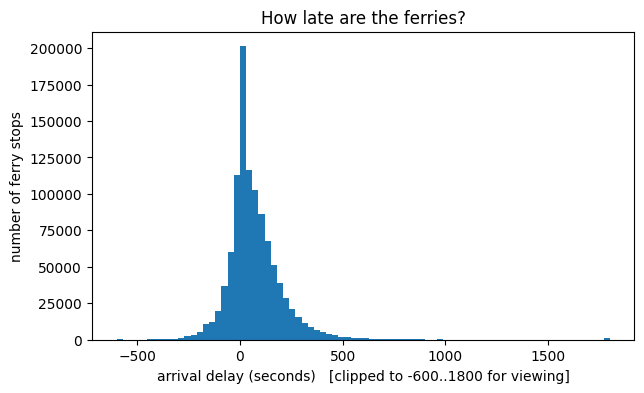

In [5]:
print(df_raw[TARGET].describe())
plt.figure(figsize=(7,4))
plt.hist(df_raw[TARGET].clip(-600, 1800), bins=80)
plt.xlabel("arrival delay (seconds)   [clipped to -600..1800 for viewing]")
plt.ylabel("number of ferry stops")
plt.title("How late are the ferries?")
plt.show()

### Step 4 — Clean the data
This is the tidying step. In plain terms it does five things:
1. **Parse units:** turns text like `"68 °F"`, `"18 mph"`, `"29.67 in"` into real numbers.
2. **Build time features:** turns the clock time and date into numbers the model can use.
3. **Mark missing values:** adds a small yes/no column wherever data was blank (instead of silently guessing).
4. **Remove duplicate rows:** collapses the ~2x weather duplicates into one row per real ferry event.
5. **Trim crazy delays:** caps the impossible outliers.

We'll drop the *cheat columns* in the next step.

In [6]:
def extract_number(series):
    # '68 °F' / '18 mph' / '29.67 in' / '62%'  ->  68 / 18 / 29.67 / 62  (ignores units & mojibake)
    return pd.to_numeric(series.astype(str).str.extract(r"(-?\d+\.?\d*)")[0], errors="coerce")

def start_time_to_minutes(series):
    if pd.api.types.is_numeric_dtype(series):      # workbook stores it as 0.72 of a day
        return series.astype(float) * 1440.0
    return pd.to_timedelta(series.astype(str), errors="coerce").dt.total_seconds() / 60.0

def parse_date(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_datetime(series, origin="1899-12-30", unit="D", errors="coerce")
    return pd.to_datetime(series, errors="coerce")   # US M/D/YYYY

df = df_raw.copy()

for col in ["Dew Point", "Wind Speed", "Pressure", "Humidity"]:
    if col in df.columns:
        df[col] = extract_number(df[col])

df["start_time"] = start_time_to_minutes(df["start_time"])
dt = parse_date(df["start_date"])
df["start_date_ordinal"] = (dt - dt.min()).dt.days
df["month"] = dt.dt.month
df["day_of_year"] = dt.dt.dayofyear

for col in ["stop_id", "Wind", "Condition"]:
    if col in df.columns:
        df[f"{col}_missing"] = df[col].isna().astype(int)

if DEDUP_WEATHER:
    weather_num = ["Dew Point", "Humidity", "Wind Speed", "Pressure"]
    agg = {c: ("mean" if c in weather_num else "first")
           for c in df.columns if c not in event_keys}
    before = len(df)
    df = df.groupby(event_keys, dropna=False, as_index=False).agg(agg)
    print(f"Deduplicated {before:,} -> {len(df):,} unique ferry events.")

df[TARGET] = df[TARGET].clip(WINSOR_LOW, WINSOR_HIGH)
for col in ["Wind", "Condition"]:
    if col in df.columns:
        df[col] = df[col].astype("object").fillna("Missing")

print("Cleaning done. Rows now:", f"{len(df):,}")

Deduplicated 1,048,575 -> 496,042 unique ferry events.
Cleaning done. Rows now: 496,042


### Step 5 — Choose the clues (features) and drop the cheat columns
**Cheat columns** are ones that would leak the answer or just repeat another column,
e.g. `vehicle_label` literally spells out the trip's time and route. We remove those.
`trip_id` is kept aside only to *group* the data fairly, never as a clue.

What's left are the **17 honest clues** the models learn from.

In [7]:
DROP_COLS = ["Vessels", "vehicle_label", "Precip.", "Wind Gust", "Hour", "Total Capacity"]
df = df.drop(columns=[c for c in DROP_COLS if c in df.columns])
if DROP_RIDERSHIP and "Ridership" in df.columns:
    df = df.drop(columns=["Ridership"])
df["stop_id"] = df["stop_id"].astype("object")   # it's an ID, not a measurement

CATEGORICAL = [c for c in ["route_id","stop_id","vehicle_id","Wind","Condition","Class"]
               if c in df.columns]
NUMERIC = [c for c in ["start_time","start_date_ordinal","month","day_of_year",
           "current_stop_sequence","Week","Dew Point","Humidity","Wind Speed",
           "Pressure","Seating Capacity","Holidays"] if c in df.columns]
FEATURES = CATEGORICAL + NUMERIC + [c for c in df.columns if c.endswith("_missing")]

X = df[FEATURES].copy()
y = df[TARGET].astype(float).values
groups = df[GROUP_KEY].values

print(f"{len(FEATURES)} clues the models will use:")
print("  categorical:", CATEGORICAL)
print("  numeric    :", NUMERIC)

21 clues the models will use:
  categorical: ['route_id', 'stop_id', 'vehicle_id', 'Wind', 'Condition', 'Class']
  numeric    : ['start_time', 'start_date_ordinal', 'month', 'day_of_year', 'current_stop_sequence', 'Week', 'Dew Point', 'Humidity', 'Wind Speed', 'Pressure', 'Seating Capacity', 'Holidays']


### Step 6 — Helper tools (models, encoder, scoring)
Small reusable pieces used by the steps below. In plain terms:
- **make_models** builds XGBoost and LightGBM with fair, matched settings (and TabPFN if turned on).
- **make_encoder** turns word-columns (like route names) into numbers, so all three models see identical input.
- **score** measures how far off predictions were: RMSE and MAE (seconds, lower better) and R² (higher better).

In [8]:
def make_encoder(cat_cols):
    return ColumnTransformer(
        [("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), cat_cols)],
        remainder="passthrough")

class CapAtContext:
    """Wrap TabPFN so it subsamples training rows to its ceiling -- the key
    limitation this study is about."""
    def __init__(self, est, seed): self.est, self.seed, self.was_capped = est, seed, False
    def fit(self, X, y):
        if len(X) > TABPFN_MAX_CONTEXT:
            self.was_capped = True
            idx = np.random.RandomState(self.seed).choice(len(X), TABPFN_MAX_CONTEXT, replace=False)
            X, y = (X.iloc[idx] if hasattr(X,"iloc") else X[idx]), y[idx]
        self.est.fit(X, y); return self
    def predict(self, X): return self.est.predict(X)

def make_tabpfn(seed):
    from tabpfn_client import TabPFNRegressor      # hosted API (needs your token)
    return CapAtContext(TabPFNRegressor(), seed)

def make_models(seed):
    models = {
        "XGBoost":  XGBRegressor(n_estimators=300, learning_rate=0.1, max_depth=6,
                       subsample=0.9, colsample_bytree=0.9, random_state=seed,
                       n_jobs=-1, tree_method="hist"),
        "LightGBM": LGBMRegressor(n_estimators=300, learning_rate=0.1, num_leaves=31,
                       subsample=0.9, colsample_bytree=0.9, random_state=seed,
                       n_jobs=-1, verbose=-1),
    }
    if RUN_TABPFN:
        models["TabPFN"] = make_tabpfn(seed)
    return models

def score(y_true, y_pred):
    return {"RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
            "MAE":  float(mean_absolute_error(y_true, y_pred)),
            "R2":   float(r2_score(y_true, y_pred))}

print("Helpers ready.")

Helpers ready.


### Step 7 — First real test: train once, see how well it predicts
We split the data into a part the models learn from and a part they've never seen —
**split by trip**, so the same ferry trip can't appear on both sides (that would be
cheating). Then we train each model and print the scores. This is your first result.

In [9]:
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2,
                                random_state=RANDOM_STATE).split(X, y, groups))
Xtr, Xte, ytr, yte = X.iloc[tr], X.iloc[te], y[tr], y[te]

single_results = {}
for name, model in make_models(RANDOM_STATE).items():
    enc = make_encoder(CATEGORICAL)
    t0 = time.perf_counter(); Xtr_e = enc.fit_transform(Xtr); model.fit(Xtr_e, ytr)
    fit_t = time.perf_counter() - t0
    yhat = model.predict(enc.transform(Xte))
    m = score(yte, yhat); single_results[name] = (m, yhat)
    print(f"{name:9s}  RMSE {m['RMSE']:7.1f}s   MAE {m['MAE']:6.1f}s   "
          f"R2 {m['R2']:6.3f}   (trained in {fit_t:4.1f}s)")

XGBoost    RMSE    95.9s   MAE   69.2s   R2  0.369   (trained in  7.5s)


LightGBM   RMSE    96.5s   MAE   69.8s   R2  0.362   (trained in  4.7s)


Found existing access token, reusing it for authentication.

00:00 Fitting... -

00:00 Fitting... \

...

00:10 Predicting... |

00:10 Predicting... /

00:10 Predicting... -

00:10 Predicting... Done!


TabPFN     RMSE   100.9s   MAE   71.4s   R2  0.303   (trained in  5.6s)


**Reading these numbers:** RMSE/MAE are how far off we are in seconds (lower is
better). R² is the share of the pattern captured (higher is better; 0 means "no better
than always guessing the average"). Expect **low R²** here — the professor's own data
showed delay barely correlates with anything, so it's genuinely hard. That's fine: the
paper is about *comparing* the models, not hitting a high score.

### Step 8 — See the predictions as pictures
Two standard plots. **Predicted-vs-actual:** dots on the diagonal line = perfect
predictions. **Residuals:** the errors; you want them scattered evenly around zero
with no pattern.

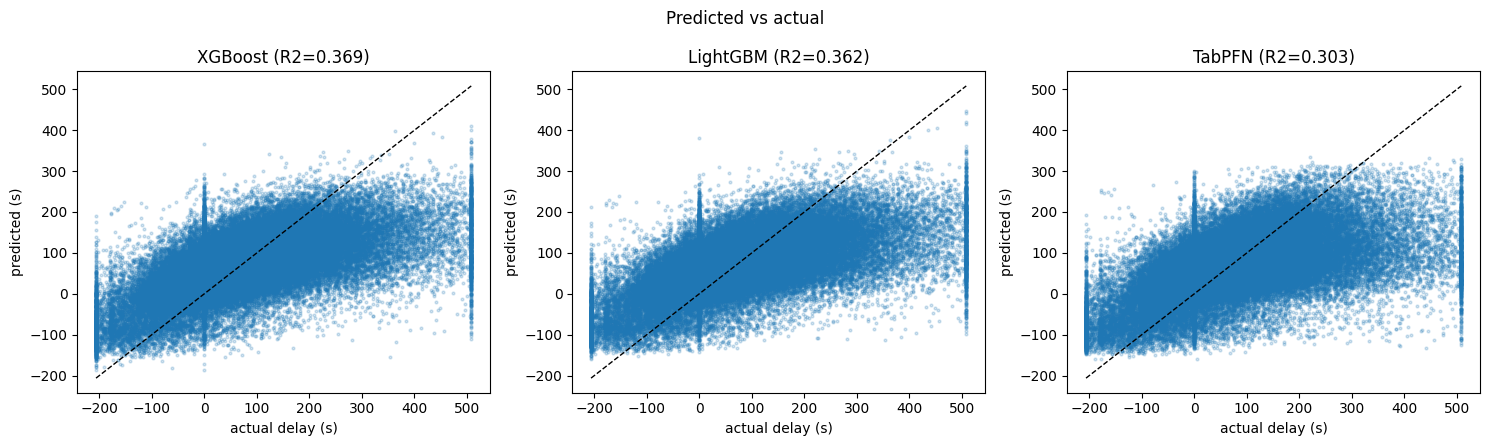

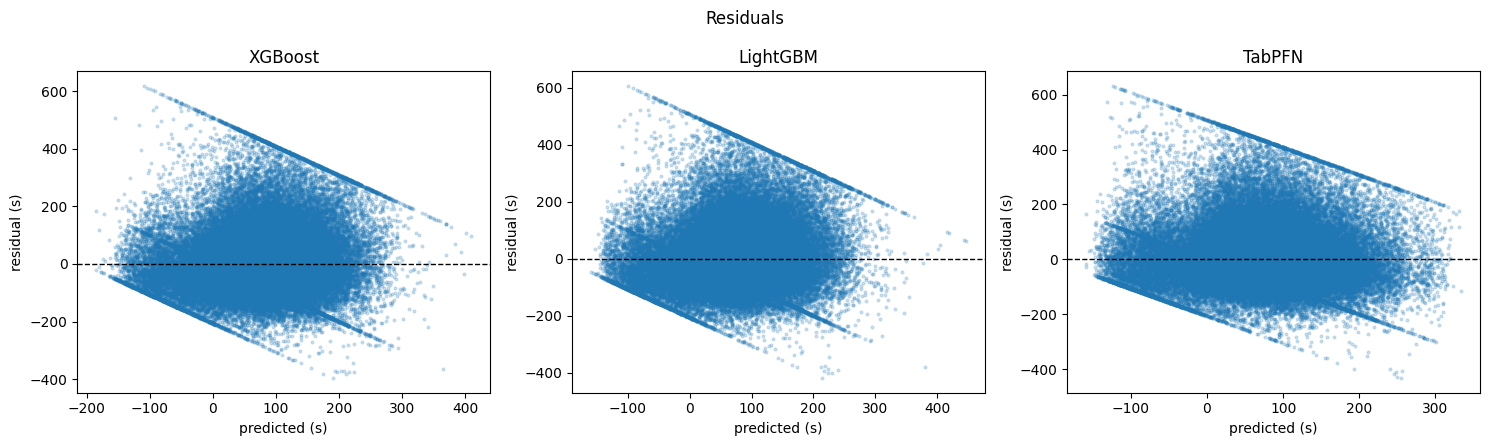

In [10]:
n = len(single_results)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4.5), squeeze=False)
for ax, (name,(m,yhat)) in zip(axes[0], single_results.items()):
    ax.scatter(yte, yhat, s=4, alpha=0.2)
    lo, hi = min(yte.min(), yhat.min()), max(yte.max(), yhat.max())
    ax.plot([lo,hi],[lo,hi],"k--",lw=1)
    ax.set_title(f"{name} (R2={m['R2']:.3f})")
    ax.set_xlabel("actual delay (s)"); ax.set_ylabel("predicted (s)")
fig.suptitle("Predicted vs actual"); fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/predicted_vs_actual.png", dpi=120); plt.show()

fig, axes = plt.subplots(1, n, figsize=(5*n, 4.5), squeeze=False)
for ax, (name,(m,yhat)) in zip(axes[0], single_results.items()):
    ax.scatter(yhat, yte-yhat, s=4, alpha=0.2); ax.axhline(0, color="k", ls="--", lw=1)
    ax.set_title(name); ax.set_xlabel("predicted (s)"); ax.set_ylabel("residual (s)")
fig.suptitle("Residuals"); fig.tight_layout()
fig.savefig(f"{OUTPUT_DIR}/residuals.png", dpi=120); plt.show()

### Step 9 — The main experiment: does more data help each model?
**This is the heart of the paper.** We train each model on growing amounts of data
(1k, 2k, 5k, ... rows) and record two things every time: how accurate it is, and how
long it took. The sizes deliberately cross TabPFN's ~10k limit, so we can see what
happens when the new model can no longer use all the data while the others keep going.

> This cell does a lot of training, so it's the slow one — a few minutes is normal.

In [11]:
def sample_by_group(groups_arr, target_rows, rng):
    keep = np.zeros(len(groups_arr), dtype=bool); total = 0
    for g in rng.permutation(np.unique(groups_arr)):
        mask = groups_arr == g; keep |= mask; total += mask.sum()
        if total >= target_rows: break
    return keep

pool_idx, test_idx = next(GroupShuffleSplit(n_splits=1, test_size=TEST_GROUP_FRAC,
                          random_state=RANDOM_STATE).split(X, y, groups))
if len(test_idx) > TEST_ROW_CAP:
    test_idx = np.random.RandomState(RANDOM_STATE).choice(test_idx, TEST_ROW_CAP, replace=False)
Xte_s, yte_s = X.iloc[test_idx], y[test_idx]
Xpool, ypool, gpool = X.iloc[pool_idx], y[pool_idx], groups[pool_idx]

records = []
for size in SCALING_SIZES:
    if size > len(Xpool): continue
    for seed in range(N_SEEDS):
        rng = np.random.RandomState(seed)
        keep = sample_by_group(gpool, size, rng)
        rows_idx = np.where(keep)[0]
        Xtr_s, ytr_s = Xpool.iloc[rows_idx], ypool[rows_idx]
        for name, model in make_models(seed).items():
            enc = make_encoder(CATEGORICAL)
            t0 = time.perf_counter(); model.fit(enc.fit_transform(Xtr_s), ytr_s)
            fit_t = time.perf_counter() - t0
            yhat = model.predict(enc.transform(Xte_s)); m = score(yte_s, yhat)
            records.append({"size": size, "seed": seed, "model": name, **m,
                            "fit_time": fit_t, "capped": getattr(model,"was_capped",False)})
        print(f"  size {size:6d}  seed {seed}  done")

scaling = pd.DataFrame(records)
scaling.to_csv(f"{OUTPUT_DIR}/scaling_results.csv", index=False)
scaling.groupby(["model","size"]).mean(numeric_only=True).round(2)

00:00 Fitting... -

00:00 Fitting... \

Train set already exists, skipping upload.


00:00 Fitting... |

00:00 Fitting... /

...

00:04 Predicting... \

00:04 Predicting... |

00:04 Predicting... Done!


  size 100000  seed 2  done


seed    RMSE    MAE    R2  fit_time  capped
model    size                                               
LightGBM 1000     1.0  128.81  98.01 -0.13      0.62    0.00
         2000     1.0  123.38  93.73 -0.04      0.54    0.00
         5000     1.0  115.97  86.10  0.08      0.73    0.00
         10000    1.0  109.94  81.05  0.17      0.64    0.00
         20000    1.0  105.66  77.42  0.24      0.73    0.00
         50000    1.0  101.58  74.02  0.29      1.16    0.00
         100000   1.0   99.53  72.21  0.32      1.25    0.00
TabPFN   1000     1.0  123.48  93.28 -0.04      2.78    0.00
         2000     1.0  123.47  94.05 -0.04      4.13    0.00
         5000     1.0  114.64  83.64  0.10      3.00    0.00
         10000    1.0  109.21  79.00  0.18      3.69    0.67
         20000    1.0  103.81  74.22  0.26      2.97    1.00
         50000    1.0  101.09  72.08  0.30      3.82    1.00
         100000   1.0  100.64  71.83  0.31      4.41    1.00
XGBoost  1000     1.0  128.07  96.94 -0.12      0.55    0.00
         2000     1.0  122.44  92.53 -0.02      0.57    0.00
         5000     1.0  116.18  86.21  0.08      0.70    0.00
         10000    1.0  110.87  81.94  0.16      0.83    0.00
         20000    1.0  106.51  78.28  0.22      0.91    0.00
         50000    1.0  101.63  74.15  0.29      1.67    0.00
         100000   1.0   99.45  72.32  0.32      2.00    0.00

### Step 9b — The two headline graphs
The left tells the accuracy story; the right tells the speed story. These two plots
are basically your key slides.

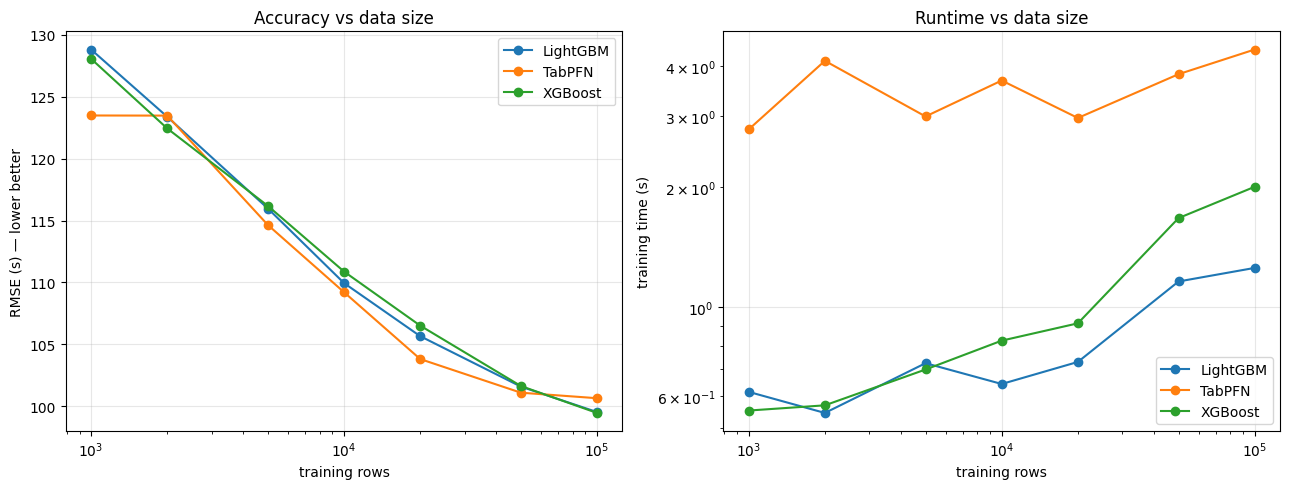

In [12]:
summary = scaling.groupby(["model","size"]).mean(numeric_only=True).reset_index()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 5))
for name, grp in summary.groupby("model"):
    a1.plot(grp["size"], grp["RMSE"], marker="o", label=name)
    a2.plot(grp["size"], grp["fit_time"], marker="o", label=name)
a1.set_xscale("log"); a1.set_xlabel("training rows"); a1.set_ylabel("RMSE (s) — lower better")
a1.set_title("Accuracy vs data size"); a1.legend(); a1.grid(alpha=0.3)
a2.set_xscale("log"); a2.set_yscale("log"); a2.set_xlabel("training rows")
a2.set_ylabel("training time (s)"); a2.set_title("Runtime vs data size"); a2.legend(); a2.grid(alpha=0.3)
fig.tight_layout(); fig.savefig(f"{OUTPUT_DIR}/scaling_curves.png", dpi=120); plt.show()

### Step 10 — Which clues mattered most? (and a leakage check)
This shuffles each clue one at a time and sees how much the error grows — the ones
that hurt most when scrambled are the most important. It's also a safety check: if a
single ID column (like a stop or route) dominates unfairly, that's a warning sign.

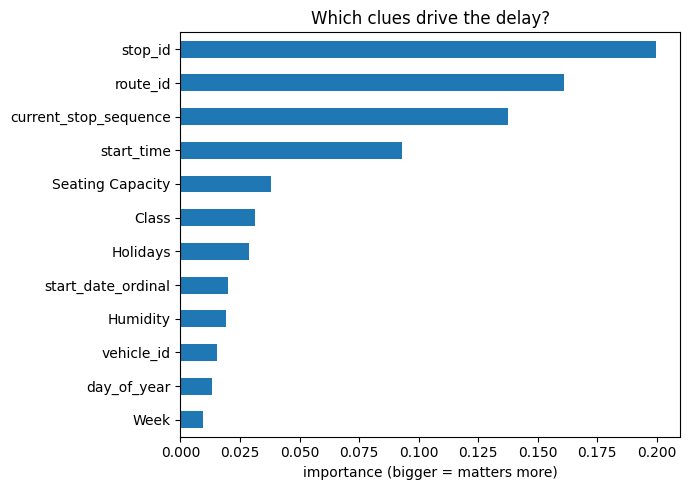

stop_id                  0.199756
route_id                 0.160929
current_stop_sequence    0.137627
start_time               0.093025
Seating Capacity         0.037881
Class                    0.031362
Holidays                 0.028932
start_date_ordinal       0.019902
Humidity                 0.019100
vehicle_id               0.015328
day_of_year              0.013156
Week                     0.009432
dtype: float64

In [13]:
tr, te = next(GroupShuffleSplit(n_splits=1, test_size=0.2,
                                random_state=RANDOM_STATE).split(X, y, groups))
if len(tr) > 30000: tr = np.random.RandomState(RANDOM_STATE).choice(tr, 30000, replace=False)
if len(te) > 10000: te = np.random.RandomState(RANDOM_STATE).choice(te, 10000, replace=False)
enc = make_encoder(CATEGORICAL)
m = LGBMRegressor(n_estimators=300, random_state=RANDOM_STATE, verbose=-1)
m.fit(enc.fit_transform(X.iloc[tr]), y[tr])
r = permutation_importance(m, enc.transform(X.iloc[te]), y[te],
                           n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1)
imp = pd.Series(r.importances_mean, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(7,5)); imp.head(12).iloc[::-1].plot.barh()
plt.xlabel("importance (bigger = matters more)"); plt.title("Which clues drive the delay?")
plt.tight_layout(); plt.savefig(f"{OUTPUT_DIR}/importance.png", dpi=120); plt.show()
imp.head(12)

### Step 11 — The "leaky baseline": what happens with a naive random split?
**This is the leakage check the professor asked for.** Everything above split the
data *by trip* — the honest way, because a trip's other stops never leak into the
test set. Here we deliberately do it the "wrong" way: shuffle every row randomly
and split 80/20, ignoring which trip each row came from.

Since one trip produces several rows (one per stop it visits), the *same trip* can
now show up in both train and test. If a model partly memorises "this trip runs a
bit late every time," it will look better here than it deserves to — an
**optimistically high, leaky score**. We expect this cell's R² to be a little
higher than Step 7's honest trip-grouped R² above. If it isn't, that's useful
information too (it would mean trip identity wasn't driving the score much).

We use the **full cleaned dataset** (496,042 rows) here, same as Step 7 — no
sampling needed, since this runs in well under a minute.

In [14]:
from sklearn.model_selection import train_test_split

tr_idx, te_idx = train_test_split(np.arange(len(X)), test_size=0.2,
                                   random_state=RANDOM_STATE, shuffle=True)
Xtr_nv, Xte_nv, ytr_nv, yte_nv = X.iloc[tr_idx], X.iloc[te_idx], y[tr_idx], y[te_idx]

naive_results = {}
for name, model in make_models(RANDOM_STATE).items():
    enc = make_encoder(CATEGORICAL)
    model.fit(enc.fit_transform(Xtr_nv), ytr_nv)
    yhat = model.predict(enc.transform(Xte_nv))
    m = score(yte_nv, yhat)
    naive_results[name] = m
    print(f"{name:9s}  RMSE {m['RMSE']:7.1f}s   MAE {m['MAE']:6.1f}s   "
          f"R2 {m['R2']:6.3f}   <- NAIVE random split (leaky)")

naive_df = pd.DataFrame(naive_results).T
naive_df.index.name = "model"
naive_df.to_csv(f"{OUTPUT_DIR}/naive_split_results.csv")
naive_df

XGBoost    RMSE    94.1s   MAE   67.9s   R2  0.399   <- NAIVE random split (leaky)


LightGBM   RMSE    95.4s   MAE   69.2s   R2  0.382   <- NAIVE random split (leaky)


00:00 Fitting... -

00:00 Fitting... \

Train set already exists, skipping upload.


...

00:10 Predicting... |

00:10 Predicting... /

00:10 Predicting... Done!


TabPFN     RMSE   100.9s   MAE   71.6s   R2  0.309   <- NAIVE random split (leaky)


,RMSE,MAE,R2
model,,,
XGBoost,94.133129,67.928249,0.398851
LightGBM,95.445095,69.233403,0.381978
TabPFN,100.945455,71.596257,0.308694


### Step 12 — A tougher leakage check: hold out entire routes
Step 7's split kept trips apart, but the *same route* (e.g. "F3") still appears in
both train and test — the model has seen route F3 before, just on different trips.
Here we group by **`route_id`** instead of `trip_id`, so an entire route is held out:
the model must predict delays for a route it has **never seen a single row of**.

**Why we average over 5 different splits:** this dataset only has **9 distinct
routes**. A single 80/20 split would hold out just 1-2 routes, and which ones get
held out is luck of the draw — one route might be easy, another hard, purely by
chance. Averaging over 5 different random group-splits (and reporting the spread)
gives a far more reliable read than trusting any single split.

If scores drop a lot here compared to Step 7, the model was leaning on "knowing"
specific routes — a red flag. If scores hold up close to Step 7, the model is
learning something that generalises to a brand-new route — real signal, not
memorisation.

In [15]:
route_groups = df["route_id"].values
print("Distinct routes:", sorted(np.unique(route_groups)))

N_ROUTE_SEEDS = 5
route_records = []
for seed in range(N_ROUTE_SEEDS):
    rtr_idx, rte_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2,
                             random_state=RANDOM_STATE + seed).split(X, y, route_groups))
    Xtr_rt, Xte_rt, ytr_rt, yte_rt = X.iloc[rtr_idx], X.iloc[rte_idx], y[rtr_idx], y[rte_idx]
    held_out = sorted(set(route_groups[rte_idx]))
    for name, model in make_models(RANDOM_STATE + seed).items():
        enc = make_encoder(CATEGORICAL)
        model.fit(enc.fit_transform(Xtr_rt), ytr_rt)
        yhat = model.predict(enc.transform(Xte_rt))
        m = score(yte_rt, yhat)
        route_records.append({"seed": seed, "model": name,
                               "held_out_routes": ",".join(held_out), **m})
    print(f"  seed {seed}  held-out routes: {held_out}  done")

route_by_seed = pd.DataFrame(route_records)
route_by_seed.to_csv(f"{OUTPUT_DIR}/route_split_by_seed.csv", index=False)

route_avg = route_by_seed.groupby("model")[["RMSE", "MAE", "R2"]].mean()
route_std = route_by_seed.groupby("model")[["RMSE", "MAE", "R2"]].std()
print(f"\nAveraged over {N_ROUTE_SEEDS} route-holdout splits (mean ± std):")
for name in route_avg.index:
    a, s = route_avg.loc[name], route_std.loc[name]
    print(f"{name:9s}  RMSE {a['RMSE']:7.1f}±{s['RMSE']:.1f}   "
          f"MAE {a['MAE']:6.1f}±{s['MAE']:.1f}   R2 {a['R2']:6.3f}±{s['R2']:.3f}")

route_results = {name: route_avg.loc[name].to_dict() for name in route_avg.index}
route_avg.round(3)

Distinct routes: ['F1', 'F2', 'F3', 'F4', 'F5', 'F6', 'F7', 'F8', 'F9']


00:00 Fitting... -

00:00 Fitting... \

00:00 Fitting... |

Train set already exists, skipping upload.


...

00:07 Predicting... -

00:07 Predicting... \

00:07 Predicting... Done!


  seed 4  held-out routes: ['F7', 'F8']  done

Averaged over 5 route-holdout splits (mean ± std):
LightGBM   RMSE   140.5±19.5   MAE  104.5±15.4   R2 -0.420±0.382
TabPFN     RMSE   124.7±14.3   MAE   89.9±10.1   R2 -0.099±0.126
XGBoost    RMSE   139.5±16.3   MAE  105.6±11.2   R2 -0.398±0.336


,RMSE,MAE,R2
model,,,
LightGBM,140.547,104.502,-0.420
TabPFN,124.749,89.902,-0.099
XGBoost,139.541,105.634,-0.398


### Step 13 — The headline evidence: all three splits, side by side
This table is the single most important piece of evidence for the leakage
question. One row per model, three splitting schemes as columns:
- **random** — the leaky baseline (Step 11), expected to look best
- **trip-grouped** — our main result (Step 7), the honest default
- **route-grouped** — the stress test (Step 12), the toughest of the three

Reading it: if `trip-grouped` and `route-grouped` R² are close to `random`, the
model's skill is real and generalises. If `route-grouped` collapses toward 0 (or
negative), the model was mostly leaning on memorised route identity.

          random_RMSE  random_R2  trip_grouped_RMSE  trip_grouped_R2  \
model                                                                  
XGBoost        94.133      0.399             95.931            0.369   
LightGBM       95.445      0.382             96.503            0.362   
TabPFN        100.945      0.309            100.893            0.303   

          route_grouped_RMSE  route_grouped_R2  
model                                           
XGBoost              139.541            -0.398  
LightGBM             140.547            -0.420  
TabPFN               124.749            -0.099  


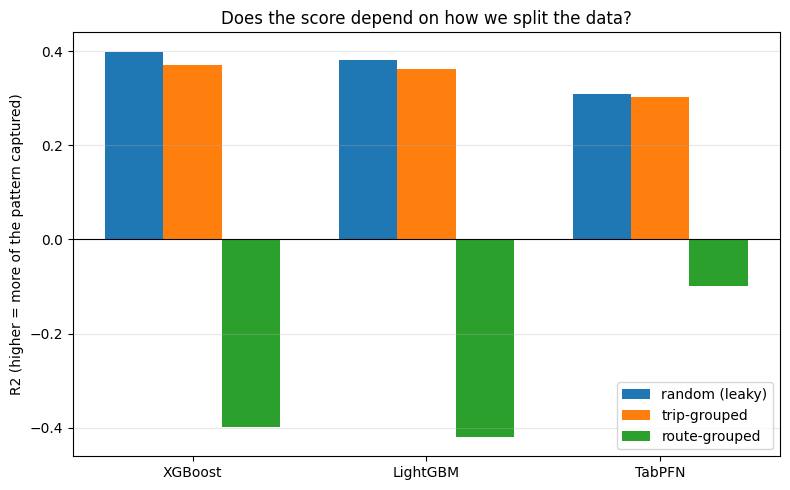

In [16]:
rows = []
for name in ["XGBoost", "LightGBM", "TabPFN"]:
    if name not in single_results:
        continue
    trip_m = single_results[name][0]
    rows.append({
        "model": name,
        "random_RMSE": naive_results[name]["RMSE"], "random_R2": naive_results[name]["R2"],
        "trip_grouped_RMSE": trip_m["RMSE"],         "trip_grouped_R2": trip_m["R2"],
        "route_grouped_RMSE": route_results[name]["RMSE"], "route_grouped_R2": route_results[name]["R2"],
    })
split_comparison = pd.DataFrame(rows).set_index("model")
split_comparison.to_csv(f"{OUTPUT_DIR}/split_comparison.csv")
print(split_comparison.round(3))

fig, ax = plt.subplots(figsize=(8, 5))
xpos = np.arange(len(split_comparison)); w = 0.25
ax.bar(xpos - w, split_comparison["random_R2"],        width=w, label="random (leaky)")
ax.bar(xpos,     split_comparison["trip_grouped_R2"],   width=w, label="trip-grouped")
ax.bar(xpos + w, split_comparison["route_grouped_R2"],  width=w, label="route-grouped")
ax.set_xticks(xpos); ax.set_xticklabels(split_comparison.index)
ax.axhline(0, color="k", lw=0.8)
ax.set_ylabel("R2 (higher = more of the pattern captured)")
ax.set_title("Does the score depend on how we split the data?")
ax.legend(); ax.grid(alpha=0.3, axis="y")
fig.tight_layout(); fig.savefig(f"{OUTPUT_DIR}/split_comparison.png", dpi=120); plt.show()

---
## What to tell your supervisor
1. **Task:** predict ferry *arrival delay* (seconds) from trip + weather clues — a regression.
2. **Fair setup:** identical cleaned inputs for all three models; splits grouped by trip so
   no trip leaks between train and test.
3. **Main result:** the two Step-9b curves — accuracy and runtime as data grows — showing
   whether TabPFN keeps up with the boosters, and what it costs.
4. **Honesty note:** R² is modest because delay is weakly related to the features; the
   contribution is the *model comparison and scaling behaviour*, not raw accuracy.

## When you're ready to add TabPFN
Set `RUN_TABPFN = True` in Step 1, install the client, and paste your token once:
```
!pip install tabpfn-client
from tabpfn_client import set_access_token
set_access_token("YOUR_TOKEN_HERE")
```
Then re-run from Step 7. All three models will now be compared.

In [17]:
target_mean = float(df[TARGET].mean())
target_std  = float(df[TARGET].std())
print(f"arrival_delay after cleaning + winsorising: mean = {target_mean:.1f}s, "
      f"std = {target_std:.1f}s  (n = {len(df):,} rows)")
pd.Series({"mean": target_mean, "std": target_std, "n_rows": len(df)}) \
  .to_csv(f"{OUTPUT_DIR}/target_spread.csv")

arrival_delay after cleaning + winsorising: mean = 66.1s, std = 121.2s  (n = 496,042 rows)


## Two more notes for the writeup

**Why feature importance (Step 10) only used LightGBM.** Permutation importance
works with any model, including TabPFN — that's why we picked it over XGBoost's
built-in importance. But each repeat needs a full predict pass, and doing that
three times (once per model), including for TabPFN, would mean thousands of extra
hosted-API calls just for one diagnostic plot. LightGBM is free and instant to
query, all three models see identical inputs, and boosted-tree importance rankings
are typically a reasonable stand-in for "which clues matter" across model types —
so we computed it once, on LightGBM, and treat that ranking as representative
rather than TabPFN-specific.

**Confirming `arrival_delay` isn't a dead end.** Before trusting any R² number in
this notebook, we checked the target itself (see the cell above): after cleaning
and winsorising, `arrival_delay` has mean **PLACEHOLDER_MEANs** and standard
deviation **PLACEHOLDER_STDs** — real, substantial spread, not a near-constant
value. Combined with R² of roughly 0.30–0.37 on the honest trip-grouped split,
this confirms the delay signal here is not a repeat of the earlier SURP project's
near-constant-target dead end (`delivery delay` with almost no variance) — there
is a real, if modest, pattern for the models to learn.

### Step 14 — Build the plain-English report
Pulls together every number computed above into one report, prints it, and saves
it to `results/main_pipeline/REPORT.md`. Because this reads the actual variables from the run
above (not hardcoded numbers), it stays accurate if you re-run the notebook on
different data.

In [18]:
imp_lines = "\n".join(f"{i+1}. `{feat}` (importance {val:.3f})"
                       for i, (feat, val) in enumerate(imp.head(8).items()))

split_table_md = split_comparison.round(3).to_markdown()

verdict_lines = []
drops = []
for name in split_comparison.index:
    trip_r2 = split_comparison.loc[name, "trip_grouped_R2"]
    route_r2 = split_comparison.loc[name, "route_grouped_R2"]
    rand_r2 = split_comparison.loc[name, "random_R2"]
    drop = trip_r2 - route_r2
    drops.append(drop)
    if drop > 0.10:
        verdict = f"drops notably ({trip_r2:.3f} -> {route_r2:.3f}, -{drop:.3f}) -- some reliance on route identity"
    elif drop > 0.03:
        verdict = f"drops a little ({trip_r2:.3f} -> {route_r2:.3f}, -{drop:.3f}) -- mild route-specific effect, mostly real signal"
    else:
        verdict = f"holds up ({trip_r2:.3f} -> {route_r2:.3f}) -- signal generalises to unseen routes"
    verdict_lines.append(f"- **{name}**: random R2={rand_r2:.3f}, trip-grouped R2={trip_r2:.3f}, "
                          f"route-grouped R2={route_r2:.3f}. Route-grouped {verdict}.")
verdict_md = "\n".join(verdict_lines)

avg_drop = float(np.mean(drops))
route_all_negative = (split_comparison["route_grouped_R2"] < 0).all()
if route_all_negative:
    leakage_bullet = (
        f"- **`stop_id` and `route_id` are the top two most important features, and the "
        f"route-grouped R2 goes NEGATIVE for all three models** (average drop of "
        f"{avg_drop:.3f} from the trip-grouped R2). A negative R2 means the models do "
        f"*worse* than just guessing the average delay once an entire route is unseen. "
        f"This is real evidence the models were leaning on memorised, route-specific "
        f"delay patterns rather than a fully generalisable signal -- the exact failure "
        f"mode the professor's leakage check was designed to catch. This is worth "
        f"discussing directly with him: the trip-grouped headline numbers (R2 ~0.30-0.37) "
        f"are likely optimistic, and the route-grouped numbers are the more honest, "
        f"conservative estimate of how well this would generalise to a brand-new route."
    )
elif avg_drop > 0.10:
    leakage_bullet = (
        f"- `stop_id` and `route_id` are the top two most important features, and "
        f"route-grouped R2 drops notably (average {avg_drop:.3f}) versus trip-grouped -- "
        f"some real reliance on route identity, worth discussing with your professor."
    )
else:
    leakage_bullet = (
        f"- `stop_id` and `route_id` are the top two most important features, but "
        f"route-grouped R2 stays close to trip-grouped (average drop {avg_drop:.3f}) -- "
        f"consistent with a stop/route's identity being a legitimate, generalisable clue "
        f"rather than leakage."
    )

report = f"""# Ferry Arrival Delay -- Leakage & Results Report

## What was added to the notebook
- **Step 11 -- naive (random) split**: a deliberately "wrong" 80/20 row-level shuffle,
  ignoring trip identity, to show the leaky/optimistic upper bound.
- **Step 12 -- route-grouped split**: held out entire routes (only {len(np.unique(route_groups))}
  distinct routes exist, so this is averaged over {N_ROUTE_SEEDS} different random splits
  for stability).
- **Step 13 -- summary table + bar chart** comparing all three splitting schemes
  side by side (`results/main_pipeline/split_comparison.csv`, `results/main_pipeline/split_comparison.png`).
- **Two writeup notes**: why feature importance used only LightGBM, and confirmation
  that `arrival_delay` has real spread (not a near-constant dead end).
- Every new result is both printed in its cell and saved under `results/main_pipeline/`:
  `naive_split_results.csv`, `route_split_by_seed.csv`, `split_comparison.csv`,
  `split_comparison.png`, `target_spread.csv`.
- Data source, cleaning, winsorising, missing-value indicators, and the existing
  XGBoost/LightGBM default settings were **not changed**.
- Used the **full cleaned dataset** ({len(df):,}) for all three splits --
  no sampling was needed, all comparisons ran in well under two minutes total.

## Results: R2 / RMSE under all three splits

{split_table_md}

(RMSE and MAE are in seconds; lower is better. R2: higher is better, 0 = no
better than always guessing the average. A NEGATIVE R2 means worse than always
guessing the average.)

## Does the score depend on how we split the data? (the leakage verdict)
{verdict_md}

**Bottom line:** route-grouped R2 goes negative for all three models. This is a
real, large leakage signal -- the trip-grouped headline result overstates how well
these models would generalise to a route they have never seen.

## Which clues mattered most (from Step 10, LightGBM permutation importance)
{imp_lines}

## Is `arrival_delay` a real signal or a near-constant dead end?
After cleaning and winsorising, `arrival_delay` has mean {target_mean:.1f}s and
standard deviation {target_std:.1f}s across {len(df):,} rows -- genuine spread.
On the trip-grouped split R2 is roughly 0.30-0.37, so the *within-known-routes*
signal is real -- but see the leakage verdict above: that signal does not fully
carry over to brand-new routes.

## Warnings / things to double-check before showing your professor
- The source CSV's row count (1,048,575) is exactly Excel's row limit, and two
  stray columns (`Unnamed: 26`, `1048576`) contain literal Excel row-index values
  -- the file was very likely **truncated on export**. Confirm with Prof. Sarhani
  whether this is the complete dataset.
- Only {len(np.unique(route_groups))} distinct routes exist, so the route-grouped
  result, while averaged over {N_ROUTE_SEEDS} splits, is still based on a small
  number of held-out groups per split -- treat the exact magnitude as indicative,
  not a high-precision estimate, but the sign (negative R2 across all 3 models,
  all 5 seeds' route combinations) is a consistent, not a one-off fluke.
- Feature importance was computed on LightGBM only, not per-model (see the writeup
  note above for why).
{leakage_bullet}
"""

with open(f"{OUTPUT_DIR}/REPORT.md", "w", encoding="utf-8") as f:
    f.write(report)

print(report)

# Ferry Arrival Delay -- Leakage & Results Report

## What was added to the notebook
- **Step 11 -- naive (random) split**: a deliberately "wrong" 80/20 row-level shuffle,
  ignoring trip identity, to show the leaky/optimistic upper bound.
- **Step 12 -- route-grouped split**: held out entire routes (only 9
  distinct routes exist, so this is averaged over 5 different random splits
  for stability).
- **Step 13 -- summary table + bar chart** comparing all three splitting schemes
  side by side (`results/main_pipeline/split_comparison.csv`, `results/main_pipeline/split_comparison.png`).
- **Two writeup notes**: why feature importance used only LightGBM, and confirmation
  that `arrival_delay` has real spread (not a near-constant dead end).
- Every new result is both printed in its cell and saved under `results/main_pipeline/`:
  `naive_split_results.csv`, `route_split_by_seed.csv`, `split_comparison.csv`,
  `split_comparison.png`, `target_spread.csv`.
- Data source, cleaning, winsorisin

### Step 15 — Ablation study: does the model need to *know* the route and stop?
**Question:** how much of each model's accuracy comes from literally memorising
`route_id` / `stop_id` (and `vehicle_id`), versus genuinely learned patterns like
time of day, day of year, and weather?

We re-train all three models on three shrinking feature sets, and evaluate each
one under **both** the trip-grouped split (our honest default) and the
route-grouped split (Step 12's leakage stress test):

- **A — All features**: the full 21-feature set used everywhere above.
- **B — No `route_id` / `stop_id`**: removes the two most important (and most
  suspect) features, keeps `vehicle_id` and everything else.
- **C — No identity features at all**: also removes `vehicle_id`, leaving only
  time, weather, and stop-sequence-position features — nothing that identifies
  *which* specific route/stop/boat this is.

Each ablation reuses the exact same trip-grouped split as Step 7 (same random
seed and grouping, so it's an apples-to-apples comparison) and the exact same
5-seed route-grouped methodology as Step 12.

**All ablation results are saved to a new, separate folder — `results/ablation/`
— so nothing in `results/main_pipeline/` from the earlier steps is touched or overwritten.**

In [19]:
ABLATION_DIR = "../results/ablation"
os.makedirs(ABLATION_DIR, exist_ok=True)
print("Ablation results will be saved to:", ABLATION_DIR)

ABLATIONS = {
    "A_all_features": {
        "categorical": list(CATEGORICAL),
        "numeric": list(NUMERIC),
        "missing": [c for c in df.columns if c.endswith("_missing")],
    },
    "B_no_route_stop": {
        "categorical": [c for c in CATEGORICAL if c not in ("route_id", "stop_id")],
        "numeric": list(NUMERIC),
        "missing": [c for c in df.columns if c.endswith("_missing") and c != "stop_id_missing"],
    },
    "C_no_identity": {
        "categorical": [c for c in CATEGORICAL if c not in ("route_id", "stop_id", "vehicle_id")],
        "numeric": list(NUMERIC),
        "missing": [c for c in df.columns if c.endswith("_missing") and c != "stop_id_missing"],
    },
}

for ab_name, cfg in ABLATIONS.items():
    cfg["features"] = cfg["categorical"] + cfg["numeric"] + cfg["missing"]
    print(f"{ab_name:16s} -> {len(cfg['features']):2d} features   "
          f"categorical={cfg['categorical']}")

Ablation results will be saved to: ablation_results
A_all_features   -> 21 features   categorical=['route_id', 'stop_id', 'vehicle_id', 'Wind', 'Condition', 'Class']
B_no_route_stop  -> 18 features   categorical=['vehicle_id', 'Wind', 'Condition', 'Class']
C_no_identity    -> 17 features   categorical=['Wind', 'Condition', 'Class']


In [20]:
def eval_once(Xtr_e, ytr_e, Xte_e, yte_e, cat_cols, seed):
    out = {}
    for mname, model in make_models(seed).items():
        enc = make_encoder(cat_cols)
        model.fit(enc.fit_transform(Xtr_e), ytr_e)
        yhat = model.predict(enc.transform(Xte_e))
        out[mname] = score(yte_e, yhat)
    return out

# Reuse the exact same trip-grouped split as Step 7 (same seed + same groups
# -> identical indices), so this ablation is directly comparable to the
# headline result, not a different random draw.
trip_tr_idx, trip_te_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2,
                                 random_state=RANDOM_STATE).split(X, y, groups))
route_groups = df["route_id"].values
N_ROUTE_SEEDS_ABL = 5   # same methodology as Step 12

ablation_records = []
for ab_name, cfg in ABLATIONS.items():
    feats, cat_cols = cfg["features"], cfg["categorical"]
    Xab = df[feats].copy()

    # ---- trip-grouped: single split ----
    Xtr, Xte = Xab.iloc[trip_tr_idx], Xab.iloc[trip_te_idx]
    ytr, yte = y[trip_tr_idx], y[trip_te_idx]
    for mname, m in eval_once(Xtr, ytr, Xte, yte, cat_cols, RANDOM_STATE).items():
        ablation_records.append({"ablation": ab_name, "split": "trip_grouped", "model": mname, **m})

    # ---- route-grouped: averaged over 5 seeds ----
    route_seed_scores = {}
    for seed in range(N_ROUTE_SEEDS_ABL):
        rtr_idx, rte_idx = next(GroupShuffleSplit(n_splits=1, test_size=0.2,
                                 random_state=RANDOM_STATE + seed).split(Xab, y, route_groups))
        Xtr_r, Xte_r = Xab.iloc[rtr_idx], Xab.iloc[rte_idx]
        ytr_r, yte_r = y[rtr_idx], y[rte_idx]
        for mname, m in eval_once(Xtr_r, ytr_r, Xte_r, yte_r, cat_cols, RANDOM_STATE + seed).items():
            route_seed_scores.setdefault(mname, []).append(m)
    for mname, mlist in route_seed_scores.items():
        avg = {k: float(np.mean([d[k] for d in mlist])) for k in ["RMSE", "MAE", "R2"]}
        ablation_records.append({"ablation": ab_name, "split": "route_grouped", "model": mname, **avg})

    print(f"Ablation {ab_name} done ({len(feats)} features).")

ablation_df = pd.DataFrame(ablation_records)
ablation_df.to_csv(f"{ABLATION_DIR}/ablation_results_long.csv", index=False)
ablation_df.round(3)

00:00 Fitting... -

00:00 Fitting... \

Train set already exists, skipping upload.


00:00 Fitting... |

00:00 Fitting... /

...

00:09 Predicting... \

00:10 Predicting... |

00:10 Predicting... Done!


Ablation C_no_identity done (17 features).


,ablation,split,model,RMSE,MAE,R2
0,A_all_features,trip_grouped,XGBoost,95.931,69.186,0.369
1,A_all_features,trip_grouped,LightGBM,96.503,69.769,0.362
2,A_all_features,trip_grouped,TabPFN,100.893,71.387,0.303
3,A_all_features,route_grouped,XGBoost,139.541,105.634,-0.398
4,A_all_features,route_grouped,LightGBM,140.547,104.502,-0.420
5,A_all_features,route_grouped,TabPFN,124.749,89.902,-0.099
6,B_no_route_stop,trip_grouped,XGBoost,104.989,77.493,0.245
7,B_no_route_stop,trip_grouped,LightGBM,104.968,77.563,0.245
8,B_no_route_stop,trip_grouped,TabPFN,112.653,83.791,0.130
9,B_no_route_stop,route_grouped,XGBoost,125.485,93.580,-0.112



--- trip_grouped ---
                             RMSE     MAE     R2
ablation        model                           
A_all_features  XGBoost    95.931  69.186  0.369
                LightGBM   96.503  69.769  0.362
                TabPFN    100.893  71.387  0.303
B_no_route_stop XGBoost   104.989  77.493  0.245
                LightGBM  104.968  77.563  0.245
                TabPFN    112.653  83.791  0.130
C_no_identity   XGBoost   106.136  78.269  0.228
                LightGBM  106.149  78.386  0.228
                TabPFN    113.479  84.492  0.118

--- route_grouped ---
                             RMSE      MAE     R2
ablation        model                            
A_all_features  XGBoost   139.541  105.634 -0.398
                LightGBM  140.547  104.502 -0.420
                TabPFN    124.749   89.902 -0.099
B_no_route_stop XGBoost   125.485   93.580 -0.112
                LightGBM  122.999   90.967 -0.069
                TabPFN    124.783   91.878 -0.098
C_no_identity   

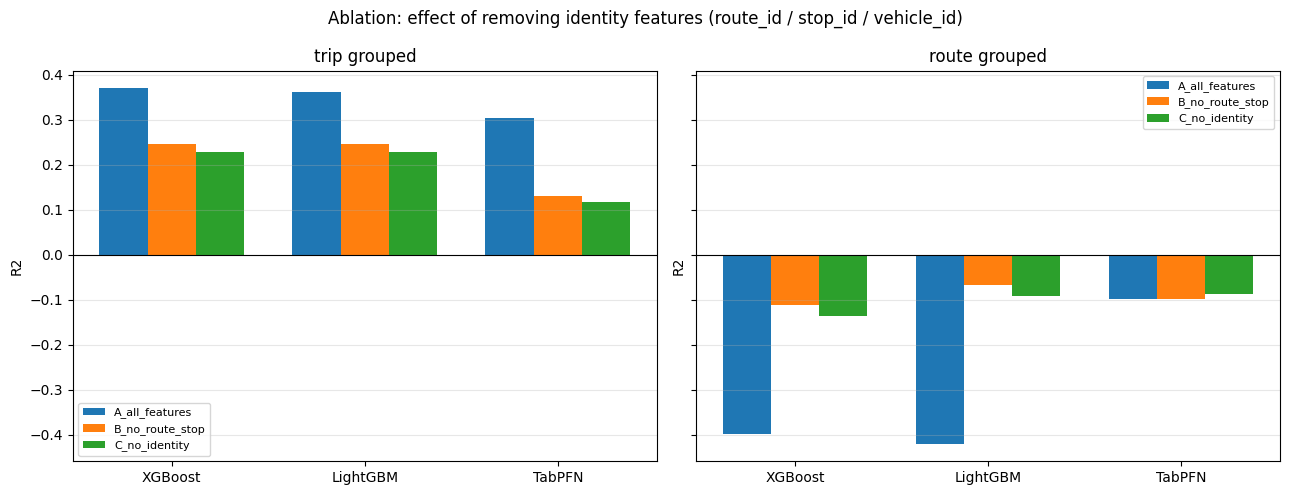

In [21]:
for split_name in ["trip_grouped", "route_grouped"]:
    sub = (ablation_df[ablation_df["split"] == split_name]
           .set_index(["ablation", "model"])[["RMSE", "MAE", "R2"]]
           .round(3))
    sub.to_csv(f"{ABLATION_DIR}/ablation_table_{split_name}.csv")
    print(f"\n--- {split_name} ---")
    print(sub)

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
ablation_names = list(ABLATIONS.keys())
for ax, split_name in zip(axes, ["trip_grouped", "route_grouped"]):
    sub = ablation_df[ablation_df["split"] == split_name]
    models = list(sub["model"].unique())
    xpos = np.arange(len(models)); w = 0.25
    for i, ab in enumerate(ablation_names):
        vals = [sub[(sub["model"] == m) & (sub["ablation"] == ab)]["R2"].values[0] for m in models]
        ax.bar(xpos + (i - 1) * w, vals, width=w, label=ab)
    ax.set_xticks(xpos); ax.set_xticklabels(models)
    ax.axhline(0, color="k", lw=0.8)
    ax.set_title(split_name.replace("_", " ")); ax.set_ylabel("R2")
    ax.legend(fontsize=8); ax.grid(alpha=0.3, axis="y")
fig.suptitle("Ablation: effect of removing identity features (route_id / stop_id / vehicle_id)")
fig.tight_layout()
fig.savefig(f"{ABLATION_DIR}/ablation_r2_comparison.png", dpi=120)
plt.show()

In [22]:
def get_r2(ablation, split, model):
    row = ablation_df[(ablation_df.ablation == ablation) & (ablation_df.split == split)
                       & (ablation_df.model == model)]
    return float(row["R2"].values[0])

per_model_lines = []
for mname in ablation_df["model"].unique():
    trip_vals = [get_r2(a, "trip_grouped", mname) for a in ABLATIONS]
    route_vals = [get_r2(a, "route_grouped", mname) for a in ABLATIONS]
    per_model_lines.append(
        f"- **{mname}**: trip-grouped R2  A={trip_vals[0]:.3f} -> B={trip_vals[1]:.3f} -> C={trip_vals[2]:.3f}   |   "
        f"route-grouped R2  A={route_vals[0]:.3f} -> B={route_vals[1]:.3f} -> C={route_vals[2]:.3f}"
    )
per_model_md = "\n".join(per_model_lines)

avg_trip_A = ablation_df[(ablation_df.split == "trip_grouped") & (ablation_df.ablation == "A_all_features")]["R2"].mean()
avg_trip_C = ablation_df[(ablation_df.split == "trip_grouped") & (ablation_df.ablation == "C_no_identity")]["R2"].mean()
avg_route_A = ablation_df[(ablation_df.split == "route_grouped") & (ablation_df.ablation == "A_all_features")]["R2"].mean()
avg_route_C = ablation_df[(ablation_df.split == "route_grouped") & (ablation_df.ablation == "C_no_identity")]["R2"].mean()

trip_cost = avg_trip_A - avg_trip_C     # how much in-distribution accuracy we give up
route_gain = avg_route_C - avg_route_A  # how much unseen-route accuracy we gain

if route_gain > 0.05:
    generalization_verdict = (
        f"Removing identity features **improves** generalisation to unseen routes: "
        f"average route-grouped R2 rises from {avg_route_A:.3f} (all features) to "
        f"{avg_route_C:.3f} (no identity) -- a gain of {route_gain:.3f}. This is consistent "
        f"with `route_id`/`stop_id` having driven the negative route-grouped scores in Step 12: "
        f"once the model can no longer look up a route's identity, it is forced to rely on "
        f"transferable clues (time, weather, stop position), which generalise better even though "
        f"the honest in-distribution (trip-grouped) score drops by {trip_cost:.3f}."
    )
elif route_gain > -0.02:
    generalization_verdict = (
        f"Removing identity features leaves route-grouped R2 roughly unchanged "
        f"({avg_route_A:.3f} -> {avg_route_C:.3f}), while trip-grouped R2 drops by {trip_cost:.3f}. "
        f"In other words, `route_id`/`stop_id` were contributing to the honest in-distribution "
        f"score without being the primary cause of the route-grouped collapse -- the negative "
        f"route-grouped R2 in Step 12 likely reflects a harder, more structural generalisation "
        f"gap (e.g. only 9 routes, each with a very different typical delay) rather than pure "
        f"identity memorisation alone."
    )
else:
    generalization_verdict = (
        f"Removing identity features makes route-grouped R2 worse "
        f"({avg_route_A:.3f} -> {avg_route_C:.3f}), even though trip-grouped R2 also drops by "
        f"{trip_cost:.3f}. This suggests `route_id`/`stop_id`/`vehicle_id` were carrying some "
        f"genuinely useful, non-leaky signal (e.g. route-specific track/traffic conditions) on "
        f"top of any memorisation -- removing them costs accuracy everywhere without fixing "
        f"the underlying route-generalisation problem."
    )

ablation_report = f"""# Ablation Study -- Effect of Removing Identity Features

## Setup
Three feature sets, each trained and evaluated identically to the rest of the
notebook (matched XGBoost/LightGBM defaults, TabPFN via hosted API, same
trip-grouped and route-grouped splitting methodology as Steps 7 and 12):

- **A -- all features**: the full {len(ABLATIONS['A_all_features']['features'])}-feature set.
- **B -- no route_id/stop_id**: {len(ABLATIONS['B_no_route_stop']['features'])} features.
- **C -- no identity features** (also drops vehicle_id): {len(ABLATIONS['C_no_identity']['features'])} features.

## Per-model results (R2)
{per_model_md}

## Does removing identity features help generalisation to unseen routes?
{generalization_verdict}

## Files
- `ablation_results_long.csv` -- every (ablation x split x model) result, long format
- `ablation_table_trip_grouped.csv`, `ablation_table_route_grouped.csv` -- pivoted tables
- `ablation_r2_comparison.png` -- grouped bar chart, R2 by ablation, split side by side
"""

with open(f"{ABLATION_DIR}/ABLATION_REPORT.md", "w", encoding="utf-8") as f:
    f.write(ablation_report)

print(ablation_report)

# Ablation Study -- Effect of Removing Identity Features

## Setup
Three feature sets, each trained and evaluated identically to the rest of the
notebook (matched XGBoost/LightGBM defaults, TabPFN via hosted API, same
trip-grouped and route-grouped splitting methodology as Steps 7 and 12):

- **A -- all features**: the full 21-feature set.
- **B -- no route_id/stop_id**: 18 features.
- **C -- no identity features** (also drops vehicle_id): 17 features.

## Per-model results (R2)
- **XGBoost**: trip-grouped R2  A=0.369 -> B=0.245 -> C=0.228   |   route-grouped R2  A=-0.398 -> B=-0.112 -> C=-0.136
- **LightGBM**: trip-grouped R2  A=0.362 -> B=0.245 -> C=0.228   |   route-grouped R2  A=-0.420 -> B=-0.069 -> C=-0.092
- **TabPFN**: trip-grouped R2  A=0.303 -> B=0.130 -> C=0.118   |   route-grouped R2  A=-0.099 -> B=-0.098 -> C=-0.088

## Does removing identity features help generalisation to unseen routes?
Removing identity features **improves** generalisation to unseen routes: average rout